In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import shap
import dice_ml
import contextlib
import os

import warnings
warnings.filterwarnings('ignore')

/home/kansu/xai-bias-detection-credit/xai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# DATA LOADING AND PREPROCESSING

# Ensure you have 'german_credit_data.csv' in the same folder
df = pd.read_csv("german_credit_data.csv", index_col=0)

# Fill missing values with 'Unknown' to retain all data points
df.fillna("Unknown", inplace=True)

# Convert the Target Variable to binary (1 = Good Risk/Approved, 0 = Bad Risk/Denied)
df['Risk'] = df['Risk'].map({'good': 1, 'bad': 0})

# Define feature types for the pipeline
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
numerical_features = ['Age', 'Job', 'Credit amount', 'Duration']

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Split data into features (X) and target (y)
X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# MODEL TRAINING

# Use a Random Forest Classifier as 'Black-Box' model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Create the full pipeline
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', rf_model)])

# Train the model
clf.fit(X_train, y_train)

# Evaluate the model
y_pred = clf.predict(X_test)
print("MODEL PERFORMANCE:")
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

MODEL PERFORMANCE:
Model Accuracy: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.47      0.54        59
           1       0.80      0.88      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200




SHAP Explanations:


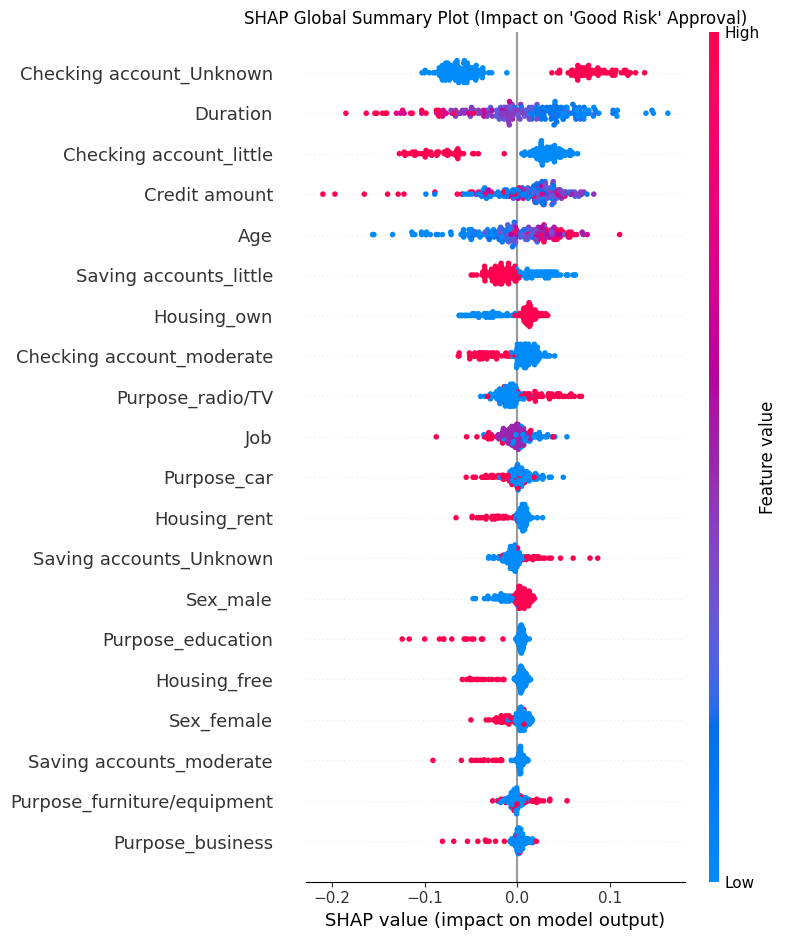

In [4]:
# EXPLANATION METHOD 1: SHAP (Global Bias Detection)

print("\nSHAP Explanations:")
shap.initjs()

# Extract preprocessed data for SHAP
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(clf.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_df)

# Handle different SHAP versions (list vs 3D array)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1] 
else:
    shap_values_to_plot = shap_values[:, :, 1] 

# Plot 1: SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Summary Plot (Impact on 'Good Risk' Approval)")
shap.summary_plot(shap_values_to_plot, X_test_df, show=False) 
plt.show()

In [6]:
# EXPLANATION METHOD 2: DiCE (Comprehensive Demographic Bias Audit)

print("\nIsolated Counterfactuals (Comprehensive Demographic Bias Audit):")

# Step A: Initialize DiCE objects
train_dataset = X_train.copy()
train_dataset['Risk'] = y_train
d = dice_ml.Data(dataframe=train_dataset, continuous_features=numerical_features, outcome_name='Risk')
m = dice_ml.Model(model=clf, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")

# Step B: Filter for all denied applicants
X_test_with_preds = X_test.copy()
X_test_with_preds['Predicted_Risk'] = y_pred
denied_applicants = X_test_with_preds[X_test_with_preds['Predicted_Risk'] == 0].drop(columns=['Predicted_Risk'])

denied_females = denied_applicants[denied_applicants['Sex'] == 'female']
denied_males = denied_applicants[denied_applicants['Sex'] == 'male']

print(f"Audit Population: {len(denied_females)} denied females, {len(denied_males)} denied males.")

# Trackers for evaluation
results = {
    'female': {'total': len(denied_females), 'sex_flips': 0, 'age_flips': 0},
    'male': {'total': len(denied_males), 'sex_flips': 0, 'age_flips': 0}
}
print("\'0' = Bad Risk / Denied: The model predicts the applicant is unlikely to repay or is a high risk, leading to a loan rejection.")
print("\'1' = Good Risk / Approved: The model predicts the applicant is a low risk, leading to loan approval.")


print("\nRunning comprehensive bias audit over all denied applicants")

for index, applicant in denied_applicants.iterrows():
    applicant_df = pd.DataFrame([applicant])
    current_sex = applicant['Sex']
    
    # TEST 1: ISOLATED SEX BIAS
    try:
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
            cf_sex = exp.generate_counterfactuals(applicant_df, total_CFs=1, desired_class="opposite", features_to_vary=['Sex'])
        if cf_sex.cf_examples_list[0].final_cfs_df is not None:
            results[current_sex]['sex_flips'] += 1
    except Exception:
        pass 

    # TEST 2: ISOLATED AGE BIAS
    try:
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
            cf_age = exp.generate_counterfactuals(applicant_df, total_CFs=1, desired_class="opposite", features_to_vary=['Age'])
        if cf_age.cf_examples_list[0].final_cfs_df is not None:
            results[current_sex]['age_flips'] += 1
    except Exception:
        pass 

# Step C: Print scientific aggregate results
print("\n--- Bias Audit Results ---")

# Female stats
f_total = results['female']['total']
f_sex_pct = (results['female']['sex_flips'] / f_total) * 100 if f_total > 0 else 0
f_age_pct = (results['female']['age_flips'] / f_total) * 100 if f_total > 0 else 0

print(f"\nDenied Female Applicants Audited: {f_total}")
print(f" -> Approved if Sex changed to Male: {results['female']['sex_flips']} ({f_sex_pct:.2f}%)")
print(f" -> Approved if ONLY Age changed: {results['female']['age_flips']} ({f_age_pct:.2f}%)")

# Male stats
m_total = results['male']['total']
m_sex_pct = (results['male']['sex_flips'] / m_total) * 100 if m_total > 0 else 0
m_age_pct = (results['male']['age_flips'] / m_total) * 100 if m_total > 0 else 0

print(f"\nDenied Male Applicants Audited: {m_total}")
print(f" -> Approved if Sex changed to Female: {results['male']['sex_flips']} ({m_sex_pct:.2f}%)")
print(f" -> Approved if ONLY Age changed: {results['male']['age_flips']} ({m_age_pct:.2f}%)")

# Disparity Check
print("\n--- Disparity Analysis ---")
print(f"Gender Bias Asymmetry: {(f_sex_pct - m_sex_pct):.2f}% difference in gender flip success rates.")
print(f"Age Bias Asymmetry: {(f_age_pct - m_age_pct):.2f}% difference in age flip success rates.")

# Show one visual example just for the code demonstration
print("\nShowing visual example for the first denied female applicant:")
print("(Note: Because DiCE is initialized with method='random', the specific counterfactual values generated and displayed below will vary each time this cell is executed.)")

if not denied_females.empty:
    sample = denied_females.head(1)
    try:
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
            cf_example = exp.generate_counterfactuals(sample, total_CFs=1, desired_class="opposite", features_to_vary=['Age'])
        cf_example.visualize_as_dataframe(show_only_changes=True)
    except Exception:
        print("Could not generate a visual counterfactual for this specific applicant.")


Isolated Counterfactuals (Comprehensive Demographic Bias Audit):
Audit Population: 12 denied females, 33 denied males.
'0' = Bad Risk / Denied: The model predicts the applicant is unlikely to repay or is a high risk, leading to a loan rejection.
'1' = Good Risk / Approved: The model predicts the applicant is a low risk, leading to loan approval.

Running comprehensive bias audit over all denied applicants

--- Bias Audit Results ---

Denied Female Applicants Audited: 12
 -> Approved if Sex changed to Male: 2 (16.67%)
 -> Approved if ONLY Age changed: 9 (75.00%)

Denied Male Applicants Audited: 33
 -> Approved if Sex changed to Female: 7 (21.21%)
 -> Approved if ONLY Age changed: 23 (69.70%)

--- Disparity Analysis ---
Gender Bias Asymmetry: -4.55% difference in gender flip success rates.
Age Bias Asymmetry: 5.30% difference in age flip success rates.

Showing visual example for the first denied female applicant:
(Note: Because DiCE is initialized with method='random', the specific cou

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,24,female,2,rent,little,little,2124,18,furniture/equipment,0



Diverse Counterfactual set (new outcome: 1)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,45,-,-,-,-,-,-,-,-,1
